# Parameter Estimation with GMM

Parameter estimation as an inverse problem: given observations, find the parameters.

**Example:** Series reaction A → B → C in a plug flow reactor. Given exit molar flows, estimate rate constants.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings

# Configure JAX to use CPU (avoids GPU/XLA compatibility issues)
import os
os.environ['JAX_PLATFORMS'] = 'cpu'

# Import reusable utilities from local module
from generative_optimization import (
    generate_samples,
    estimate_sample_size,
    best_gmm,
    best_gmm_bic,
    cluster_stats,
    validate_gmm
)

# Figure settings
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['figure.dpi'] = 150

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore', category=RuntimeWarning)

---
<a id='parameter-estimation'></a>
## 5. Parameter Estimation

Parameter estimation as an inverse problem: given observations, find the parameters.

**Example:** Series reaction A → B → C in a plug flow reactor. Given exit molar flows, estimate rate constants $k_1$ and $k_2$.

In [2]:
from scipy.integrate import solve_ivp

# Reactor parameters
nu = 1   # volumetric flow rate
Vf = 2   # reactor volume
F0 = [1, 0]  # inlet molar flows [Fa0, Fb0]

def ode(V, F, k1, k2):
    """ODE system for series reaction A -> B -> C"""
    Fa, Fb = F
    dFadV = -k1 * Fa / nu
    dFbdV = k1 * Fa / nu - k2 * Fb / nu
    return dFadV, dFbdV

In [3]:
# Generate data: sample rate constants and compute exit flows
bounds = [[0.1, 3], [0.1, 3]]
K = generate_samples(bounds, n_samples=128, seed=42)

data = []
for k1, k2 in K:
    sol = solve_ivp(ode, t_span=(0, Vf), y0=F0, args=(k1, k2))
    Fa, Fb = sol.y[:, -1]
    data.append([k1, k2, Fa, Fb])

data = np.array(data)
print(f"Data shape: {data.shape}")
print("Columns: [k1, k2, Fa_exit, Fb_exit]")

Data shape: (128, 4)
Columns: [k1, k2, Fa_exit, Fb_exit]


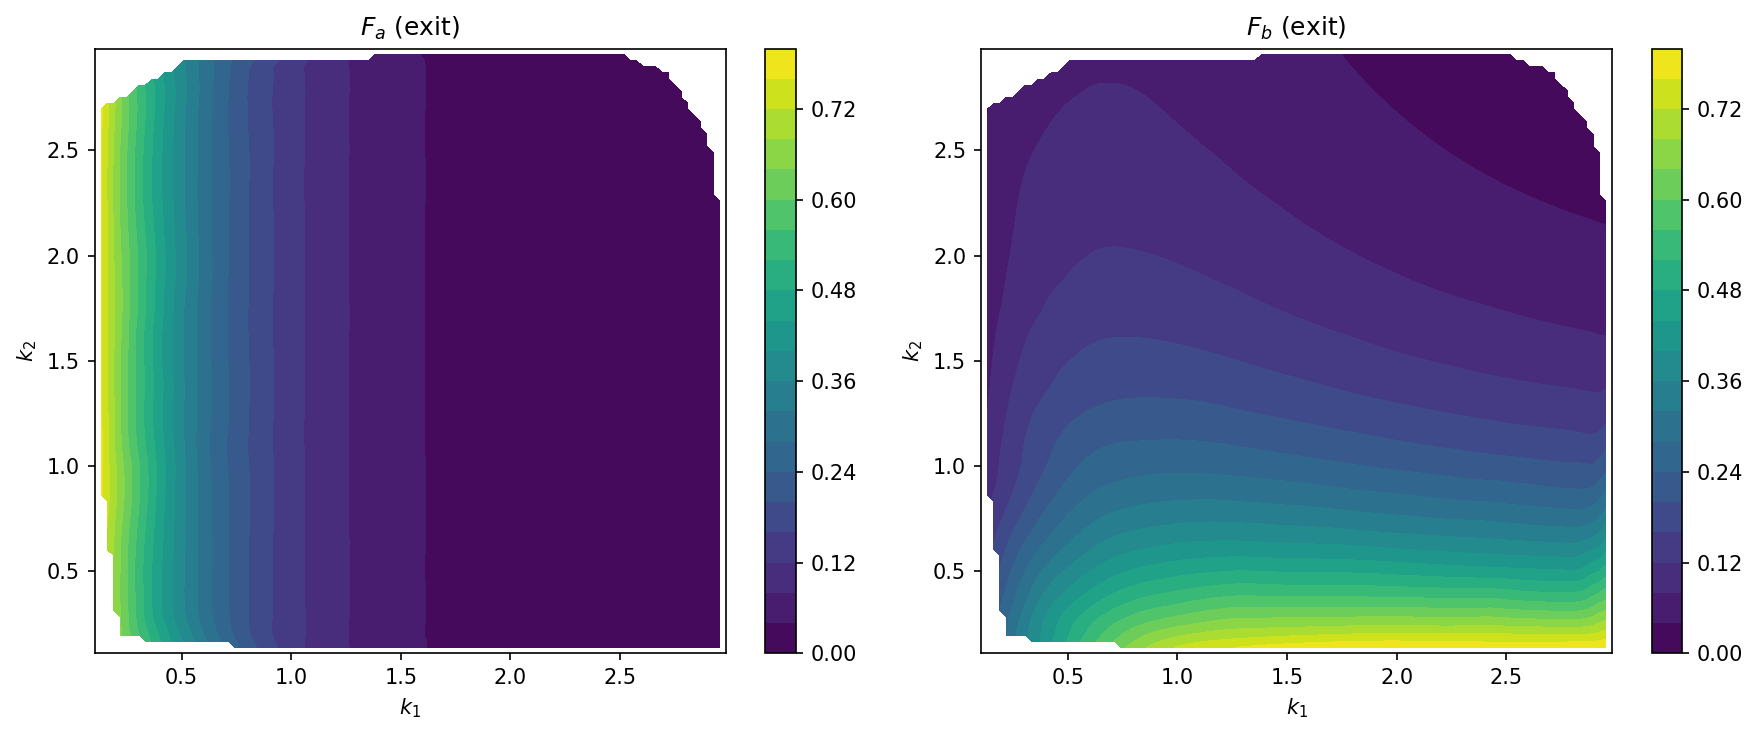

In [4]:
# Visualize the data
from scipy.interpolate import griddata

xi = np.linspace(data[:, 0].min(), data[:, 0].max(), 100)
yi = np.linspace(data[:, 1].min(), data[:, 1].max(), 100)
X, Y = np.meshgrid(xi, yi)
Z1 = griddata((data[:, 0], data[:, 1]), data[:, 2], (X, Y), method='cubic')
Z2 = griddata((data[:, 0], data[:, 1]), data[:, 3], (X, Y), method='cubic')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

c1 = axes[0].contourf(X, Y, Z1, levels=20)
axes[0].set_xlabel('$k_1$')
axes[0].set_ylabel('$k_2$')
axes[0].set_title('$F_a$ (exit)')
plt.colorbar(c1, ax=axes[0])

c2 = axes[1].contourf(X, Y, Z2, levels=20)
axes[1].set_xlabel('$k_1$')
axes[1].set_ylabel('$k_2$')
axes[1].set_title('$F_b$ (exit)')
plt.colorbar(c2, ax=axes[1])

plt.tight_layout()
plt.savefig('k1-k2-Ca-Cb.png', dpi=300, bbox_inches='tight')
plt.show()

Best model: 6 components


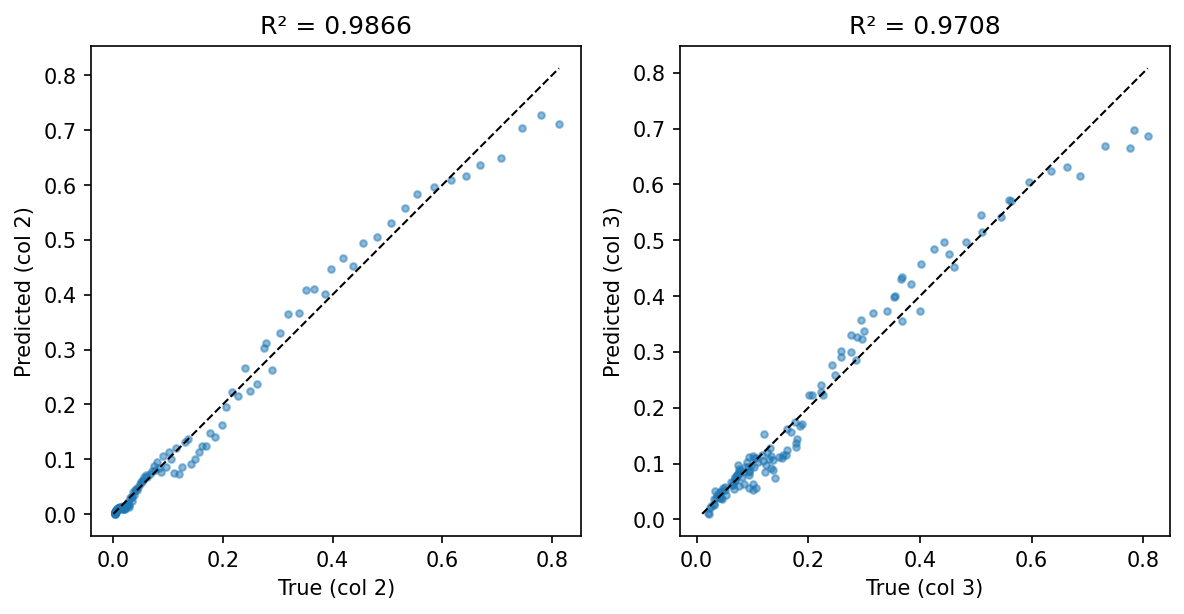

In [5]:
# Build GMM
gmm, info = best_gmm(data, verbose=False)
print(f"Best model: {info['best_k']} components")

# Validate
metrics = validate_gmm(gmm, data, input_cols=[0, 1], output_cols=[2, 3])

In [6]:
# Parameter estimation for two scenarios:
# 1. Low Fa, low Fb (both reactions fast)
# 2. Low Fa, high Fb (reaction 1 fast, reaction 2 slow)

observations = np.array([[0.02, 0.05],   # low Fa, low Fb
                         [0.02, 0.65]])  # low Fa, high Fb

P = gmm.predict([2, 3], observations)

print("Parameter estimates:")
print(f"\nScenario 1 (low Fa, low Fb - both reactions fast):")
print(f"  k1 = {P[0, 0]:.4f}, k2 = {P[0, 1]:.4f}")

print(f"\nScenario 2 (low Fa, high Fb - reaction 2 slow):")
print(f"  k1 = {P[1, 0]:.4f}, k2 = {P[1, 1]:.4f}")

Parameter estimates:

Scenario 1 (low Fa, low Fb - both reactions fast):
  k1 = 1.8211, k2 = 2.4735

Scenario 2 (low Fa, high Fb - reaction 2 slow):
  k1 = 1.8989, k2 = 0.2813


In [7]:
# Verify the estimates
for i, (obs, params) in enumerate(zip(observations, P)):
    k1, k2 = params
    Fa_exit, Fb_exit = solve_ivp(ode, t_span=(0, Vf), y0=F0, 
                                  args=(k1, k2)).y[:, -1]
    print(f"Scenario {i+1}:")
    print(f"  Estimated k = [{k1:.3f}, {k2:.3f}]")
    print(f"  Target:  Fa={obs[0]:.3f}, Fb={obs[1]:.3f}")
    print(f"  Actual:  Fa={Fa_exit:.3f}, Fb={Fb_exit:.3f}")
    print()

Scenario 1:
  Estimated k = [1.821, 2.473]
  Target:  Fa=0.020, Fb=0.050
  Actual:  Fa=0.026, Fb=0.053

Scenario 2:
  Estimated k = [1.899, 0.281]
  Target:  Fa=0.020, Fb=0.650
  Actual:  Fa=0.022, Fb=0.642



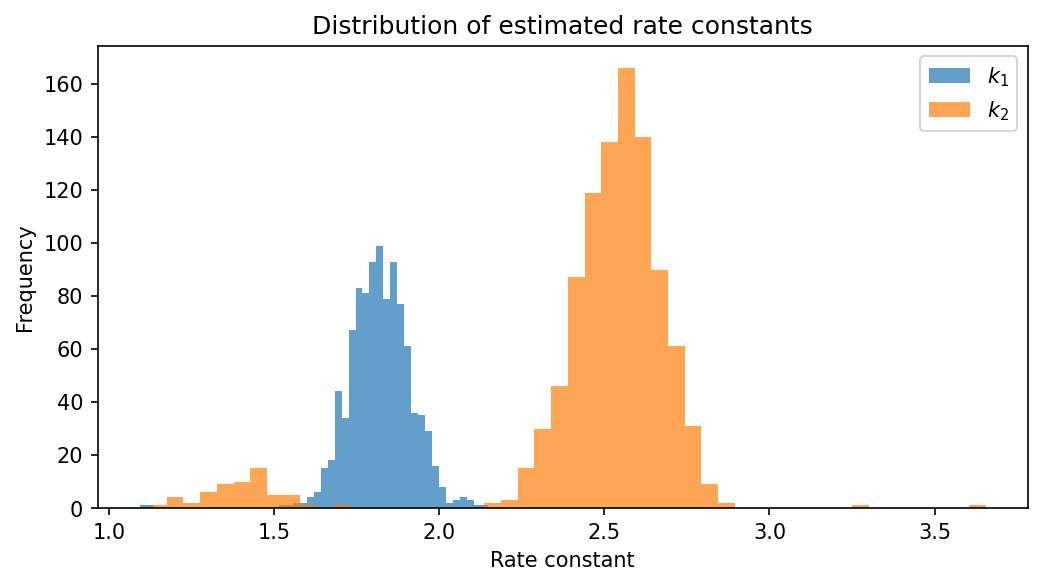

k1 = 1.820 ± 0.094
k2 = 2.478 ± 0.297


In [8]:
# Uncertainty estimation via sampling
c = gmm.condition([2, 3], np.array([[0.02, 0.05]]))
ks = c.sample(1000)

plt.figure(figsize=(8, 4))
plt.hist(ks[:, 0], bins=50, alpha=0.7, label='$k_1$')
plt.hist(ks[:, 1], bins=50, alpha=0.7, label='$k_2$')
plt.xlabel('Rate constant')
plt.ylabel('Frequency')
plt.legend()
plt.title('Distribution of estimated rate constants')
plt.show()

m, s = np.mean(ks, axis=0), np.std(ks, axis=0)
print(f"k1 = {m[0]:.3f} ± {s[0]:.3f}")
print(f"k2 = {m[1]:.3f} ± {s[1]:.3f}")

### 5.1 Caveats: Extrapolation

The generative approach fails for observations outside the training data range.

In [9]:
# Extrapolation examples (unphysical observations)
bad_observations = np.array([[0.02, -0.5],   # negative concentration
                             [0.02, 2.0]])   # Fb > F0 (impossible)

P_bad = gmm.predict([2, 3], bad_observations)

print("Extrapolation results (unreliable!):")
print(f"\nNegative Fb observation:")
print(f"  Estimated k = [{P_bad[0, 0]:.4f}, {P_bad[0, 1]:.4f}]")

print(f"\nFb > inlet flow observation:")
print(f"  Estimated k = [{P_bad[1, 0]:.4f}, {P_bad[1, 1]:.4f}]")
print("  Note: negative k2 is unphysical!")

Extrapolation results (unreliable!):

Negative Fb observation:
  Estimated k = [1.8317, 2.3442]

Fb > inlet flow observation:
  Estimated k = [2.0194, -2.1172]
  Note: negative k2 is unphysical!


In [10]:
# Verify: what happens when we use the bad parameters?
# The estimated parameters should reproduce the conditioned observations,
# but for out-of-distribution queries, they don't.

print("Verification: Do the estimated parameters produce the requested outputs?")
print("=" * 70)

for i, (obs, params) in enumerate(zip(bad_observations, P_bad)):
    k1, k2 = params
    Fa_exit, Fb_exit = solve_ivp(ode, t_span=(0, Vf), y0=F0, 
                                  args=(k1, k2)).y[:, -1]
    print(f"\nCase {i+1}: Requested Fa={obs[0]:.2f}, Fb={obs[1]:.2f}")
    print(f"  Estimated k = [{k1:.4f}, {k2:.4f}]")
    print(f"  Actual output: Fa={Fa_exit:.4f}, Fb={Fb_exit:.4f}")
    print(f"  Requested vs Actual Fb: {obs[1]:.2f} vs {Fb_exit:.4f} -- MISMATCH!")

Verification: Do the estimated parameters produce the requested outputs?

Case 1: Requested Fa=0.02, Fb=-0.50
  Estimated k = [1.8317, 2.3442]
  Actual output: Fa=0.0257, Fb=0.0587
  Requested vs Actual Fb: -0.50 vs 0.0587 -- MISMATCH!

Case 2: Requested Fa=0.02, Fb=2.00
  Estimated k = [2.0194, -2.1172]
  Actual output: Fa=0.0177, Fb=33.6884
  Requested vs Actual Fb: 2.00 vs 33.6884 -- MISMATCH!


#### The distribution doesn't warn you

A particularly insidious aspect of extrapolation is that the predicted distribution can appear narrow and confident even when the prediction is completely wrong. There is no obvious warning from the model that something is amiss.

Distribution of estimated parameters for unphysical observation (Fb=2.0):
  k1 = 2.0168 ± 0.0977
  k2 = -2.1190 ± 0.1011

Note: k2 is negative (unphysical), but the distribution is narrow!
The model appears confident in a wrong answer.


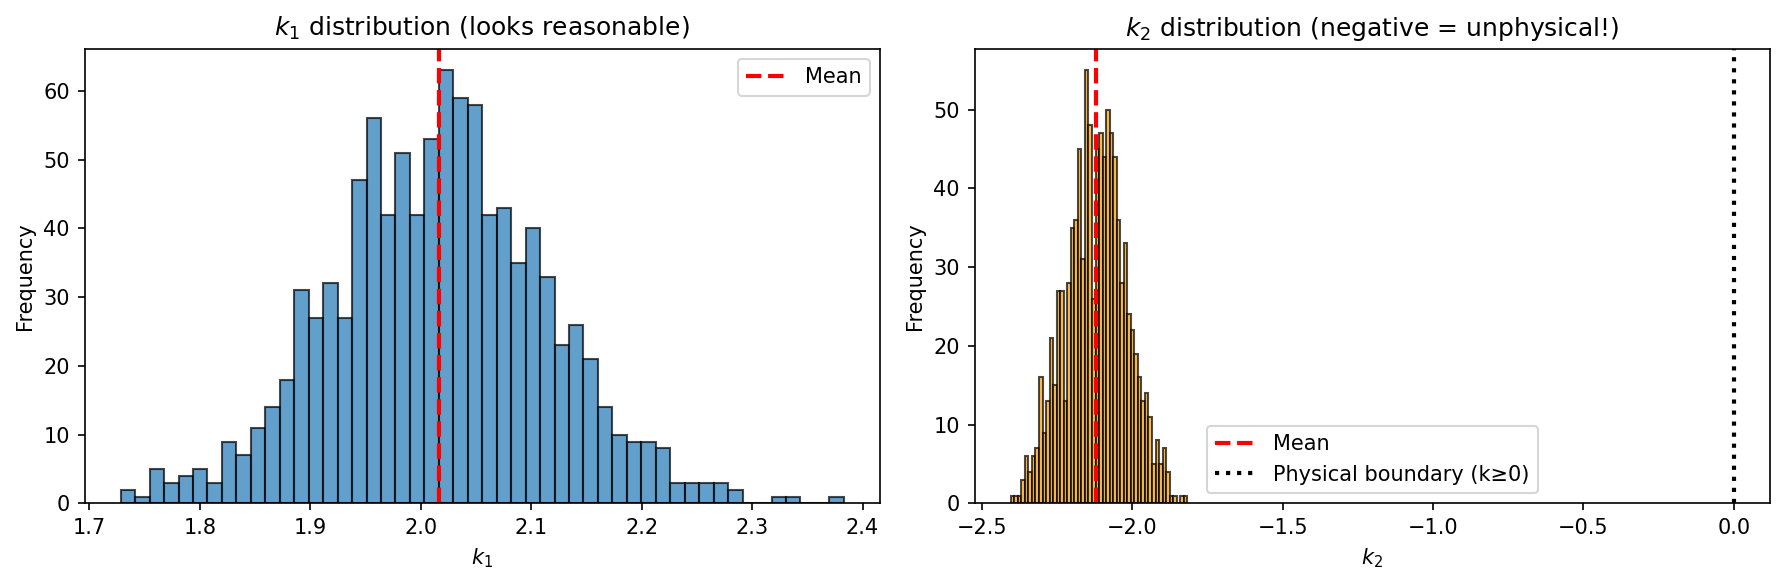


Key insight: The narrow distribution gives FALSE CONFIDENCE.
There is no warning from the model that the prediction is unreliable.


In [11]:
# Sample the distribution for the out-of-range observation (Fb=2.0, which is > F0)
# This shows that the distribution is narrow, giving no warning of the problem

c_bad = gmm.condition([2, 3], [[0.02, 2.0]])
samples_bad = c_bad.sample(1000)

print("Distribution of estimated parameters for unphysical observation (Fb=2.0):")
print(f"  k1 = {np.mean(samples_bad[:, 0]):.4f} ± {np.std(samples_bad[:, 0]):.4f}")
print(f"  k2 = {np.mean(samples_bad[:, 1]):.4f} ± {np.std(samples_bad[:, 1]):.4f}")
print(f"\nNote: k2 is negative (unphysical), but the distribution is narrow!")
print("The model appears confident in a wrong answer.")

# Visualize the distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(samples_bad[:, 0], bins=50, alpha=0.7, edgecolor='black')
axes[0].axvline(np.mean(samples_bad[:, 0]), color='r', ls='--', lw=2, label='Mean')
axes[0].set_xlabel('$k_1$')
axes[0].set_ylabel('Frequency')
axes[0].set_title('$k_1$ distribution (looks reasonable)')
axes[0].legend()

axes[1].hist(samples_bad[:, 1], bins=50, alpha=0.7, edgecolor='black', color='orange')
axes[1].axvline(np.mean(samples_bad[:, 1]), color='r', ls='--', lw=2, label='Mean')
axes[1].axvline(0, color='k', ls=':', lw=2, label='Physical boundary (k≥0)')
axes[1].set_xlabel('$k_2$')
axes[1].set_ylabel('Frequency')
axes[1].set_title('$k_2$ distribution (negative = unphysical!)')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nKey insight: The narrow distribution gives FALSE CONFIDENCE.")
print("There is no warning from the model that the prediction is unreliable.")